In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob, os, sparse, sys, warnings
sys.path.append("utils_files")
from data_utils import *
from model_utils import *

import bokeh.io
import bokeh.plotting
import bokeh.models
bokeh.io.output_notebook()

import seaborn as sns
import scipy.stats as st
plt.rcParams['figure.dpi'] = 150

import sklearn.model_selection
from sklearn.preprocessing import binarize
from sklearn.metrics import roc_auc_score, roc_curve, auc, accuracy_score, balanced_accuracy_score, average_precision_score, confusion_matrix

from Bio import SeqIO
warnings.filterwarnings("ignore")

results_path = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"

cc_df = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/criticalConcentrations_updated.csv")
who_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_resistance_variants_all.csv")

df_moxi = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MXF/data_for_model.csv")
df_rif = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/data_for_model.csv")

2023-02-21 11:47:51.279831: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-02-21 11:47:51.937180: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2023-02-21 11:47:51.937210: I tensorflow/compiler/xla/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2023-02-21 11:47:55.229254: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory
2023-

Loading BokehJS ...

In [2]:
def compare_distributions(pkl_path, drug):
    
    df = pd.read_pickle(pkl_path)
    
    train = np.log(df.loc[df.category == "original_train_set"][drug + "_midpoint"].values)
    test = np.log(df.loc[df.category == "original_test_set"][drug + "_midpoint"].values)
    
    # fig_output = pkl_path.split("/")[-1]
    # if not os.path.isdir(os.path.join("Figures", fig_output)):
    #     os.mkdir(os.path.join("Figures", fig_output))

    sm.graphics.gofplots.qqplot_2samples(train, test, xlabel="Train Set", ylabel="Test Set", line="45")
    plt.title(f"QQ Plot of {len(df)} Samples")
    #plt.savefig(os.path.join("Figures", fig_output, "qqplot.png"))
    sns.despine()
    plt.show()
    
    print(st.ks_2samp(train, test))

# Replicates Evaluation

Plot validation loss for the 10 bootstrapped replicates and the actual model on top. 

In [3]:
def plot_bootstrap_histories(path, binary=False):
        
    if binary:
        prefix = "binary_"
    else:
        prefix = ""
        
    bootstrap_histories = pd.read_csv(os.path.join(path, f"{prefix}history_replicates.csv"))
    history = pd.read_csv(os.path.join(path, f"{prefix}history.csv"))

    # the history dataframe includes patience epochs. The bootstrap replicates dataframe does not
    num_epochs = len(bootstrap_histories)
    history = history.iloc[:num_epochs, :]
    
    fig, ax = plt.subplots(figsize=(10, 4))

    for i in range(bootstrap_histories.shape[1]):
        plt.plot(bootstrap_histories.index + 1, bootstrap_histories[f"rep_{i+1}"], color="lightgray")

    #plt.plot(bootstrap_histories.index + 1, bootstrap_histories.mean(axis=1), color="red", linewidth=1.5)
    plt.plot(history.index + 1, history["val_loss"], color="red", linewidth=1.5)

    plt.xlabel("Epoch", fontsize=12)
    plot_title = "Validation Loss" + " for " + os.path.basename(path)
    plt.title(plot_title, fontsize=14)
    sns.despine()
    
    #plt.savefig(os.path.join(path, "Figures", "cv_histories.png"))
    plt.show()

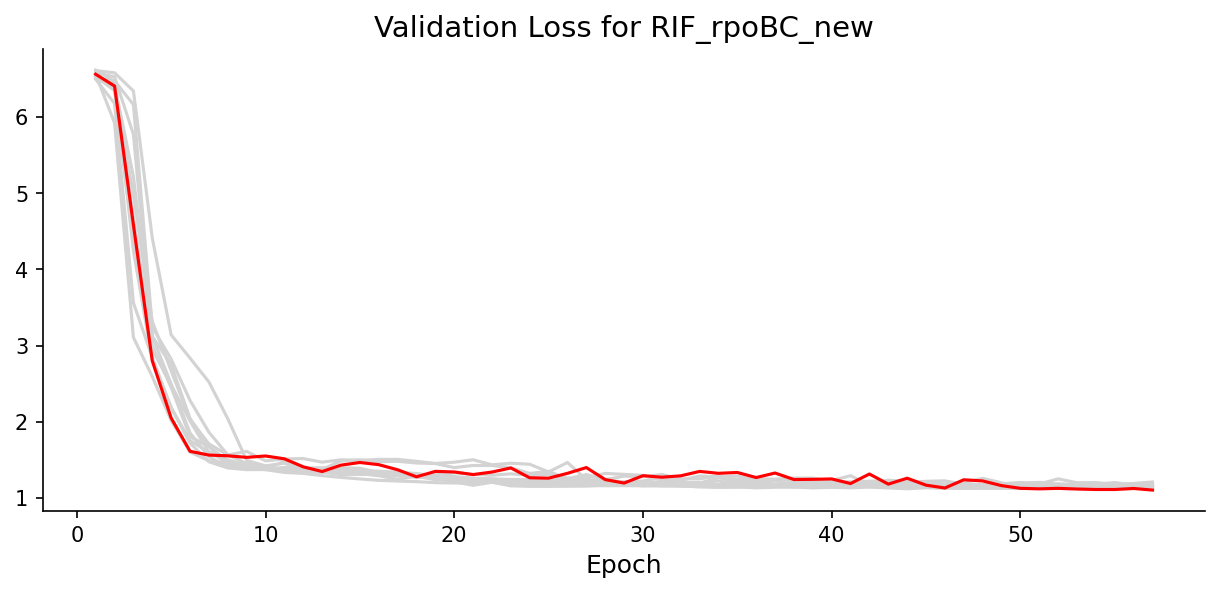

In [4]:
plot_bootstrap_histories(os.path.join(results_path, "RIF_rpoBC_new"), binary=False)

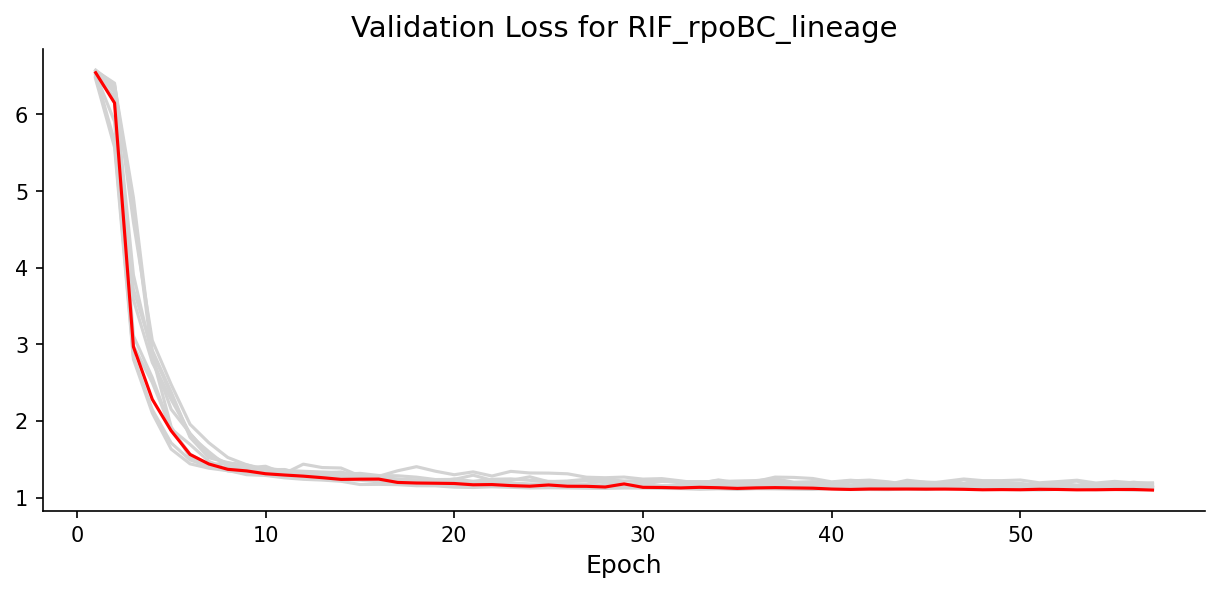

In [13]:
plot_bootstrap_histories(os.path.join(results_path, "RIF_rpoBC_lineage"), binary=False)

In [14]:
def plot_model_results(df, x_var, quant_var, title, tick_labels, plot_width, legend_loc="upper right", save_title=None):

    if x_var == "Model":
        quant_plot = df.query("CV > 0'").melt(id_vars=["Model"], value_vars=quant_var)
    else:
        quant_plot = df.query("CV > 0").melt(id_vars=["Model", x_var], value_vars=quant_var)
    
    quant_plot["Model"] = quant_plot["Model"].replace("LinReg", "Regression")
    quant_plot["Model"] = quant_plot["Model"].replace("LogReg", "Regression")
        
    palette = sns.color_palette("Set2")
    palette = palette.as_hex()
    color_dict = dict(zip(quant_plot["Model"].unique(), palette[:len(quant_plot["Model"].unique())]))

    fig, ax = plt.subplots(1, 1, figsize=(plot_width, 3.5))
    sns.stripplot(x=x_var, y="value",
                    hue="Model", 
                  dodge=True,
                    data = quant_plot,
                    palette=color_dict,
                  #order=["1", "12"],
                  hue_order=["Regression", "CNN"],
                  linewidth=0.5,
                  ax=ax
                     )



    #plt.ylim(0.5, 0.7)
    ax.get_legend().remove()
    
    legend = plt.legend(loc=legend_loc, fancybox=True, fontsize=8)
    legend.legendHandles[0]._sizes = [20]
    legend.legendHandles[1]._sizes = [20]
    
    plt.title(title, fontsize="small")
    plt.xlabel("")
    plt.ylabel(quant_var)
    plt.xticks(ticks=ax.get_xticks(), labels=tick_labels)
    
    sns.despine()
    plt.tight_layout()
    
    if save_title is None:
        plt.show()
    else:
        plt.savefig(save_title, dpi=300)

# Analyze quantitative CNN

In [48]:
def test_for_significance(x1, x2, var, alt="two-sided"):
    
    return st.ttest_rel(x1.query("CV>0")[var], x2.query("CV>0")[var], alternative=alt)[1]
        

def binary_model_analysis(path, drug, cc, num_loci, lineage=0, cv=True, plot=True, patience=25):
    
    history = pd.read_csv(os.path.join(path, "binary_history.csv"))
    pred = pd.read_csv(os.path.join(path, "binary_test_predictions.csv"))
    
    if patience != 0:
        history = history.iloc[:-patience, :]

    print(f"{len(pred)} points in validation set")
    print(f"Trained CNN for {len(history)} epochs")
    
    if plot:
        fig, ax = plt.subplots(figsize=(4, 2))

        plt.plot(history.index+1, history["val_loss"], label="Loss")
        plt.title("Validation Loss", fontsize=14)
        #plt.xlim(0, stop_epoch)

        sns.despine()
        plt.xlabel("Epoch", fontsize=10)
    
    summary_df = pd.DataFrame({"Drug": drug,
                               "Model": "CNN",
                               "Num_Loci": num_loci,
                              }, index=[0])
    
    summary_df["Num_Loci"] = "Binary"
    summary_df["CV"] = 0
    summary_df["Lineage"] = lineage
    summary_metrics_df = compute_binary_metrics(pred.y_pred_label, pred.y_test, cc, binarize=False)
    summary_df = pd.concat([summary_df, summary_metrics_df], axis=1)
    
    if cv:
        cv_results = pd.read_csv(os.path.join(path, "binary_val_results.csv"))
        cv_results["CV"] = np.arange(len(cv_results))+1
        cv_results["Num_Loci"] = "Binary"
        cv_results["Lineage"] = lineage
        return pd.concat([summary_df, cv_results])
    else:
        return summary_df
    

def quant_model_analysis(path, drug, cc, df_phenos, num_loci, lineage=0, cv=True, plot=True, patience=25):
    
    pred_df = pd.read_csv(os.path.join(path, "test_predictions.csv"))
    history = pd.read_csv(os.path.join(path, "history.csv"))
    
    if patience != 0:
        last_epoch = len(history) - patience
    else:
        last_epoch = len(history)
    
    print(f"{len(pred_df)} points in validation set")
    print(f"Trained CNN for {last_epoch} epochs")
    
    if plot:
        fig, ax = plt.subplots(1, 2, figsize=(10, 4))

        ax[0].plot(history.index+1, history["val_loss"], label="Loss")
        ax[0].set_title("Validation Loss", fontsize=14)
        ax[0].set_xlabel("Epoch", fontsize=10)
        ax[0].axvline(x=last_epoch, color="black", linestyle="dashed")
        
        values = np.vstack([pred_df["y_pred"], pred_df["y_test"]])
        kernel = st.gaussian_kde(values)(values)

        sns.scatterplot(
            data=pred_df,
            x="y_pred",
            y="y_test",
            c=kernel,
            cmap="Blues",
            linewidth=0.25,
            edgecolor="lightgray",
            ax=ax[1]
        )

        max_val = np.max([pred_df.y_pred, pred_df.y_test]) * 1.1
        min_val = np.min([pred_df.y_pred, pred_df.y_test]) * 1.1

        ax[1].set_xlabel("Predicted log(MIC)")
        ax[1].set_ylabel("Actual log(MIC)")
        ax[1].set_xlim(min_val, max_val)
        ax[1].set_ylim(min_val, max_val)

        sns.despine()
        
    binned_mae, binned_mse, within_1bin = boundedLoss_predict(pred_df, "y_pred", "y_test", "lower", "upper")
    mae = np.mean(np.abs(pred_df.y_pred - pred_df.y_test))
    mse = np.mean((pred_df.y_pred - pred_df.y_test)**2)
    
    summary_df = pd.DataFrame({"Drug": drug,
                               "Model": "CNN",
                               "Num_Loci": num_loci,
                               "Binned_MAE": binned_mae,
                               "Binned_MSE": binned_mse,
                               "MAE": mae,
                               "MSE": mse,
                               "Within_1bin": within_1bin,
                               "Pearson": st.pearsonr(pred_df.y_pred, pred_df.y_test)[0],
                               "Lineage": lineage,
                               "CV": 0
                              }, index=[0])
    
    binary_metrics_df = compute_binary_metrics(pred_df.y_test, pred_df.y_pred, cc, binarize=True)
    summary_df = pd.concat([summary_df, binary_metrics_df], axis=1)
    
    if cv:
        cv_results = pd.read_csv(os.path.join(path, "val_results.csv"))
        cv_results["CV"] = np.arange(len(cv_results))+1
        cv_results["Num_Loci"] = num_loci
        cv_results["Lineage"] = lineage
        return pd.concat([summary_df, cv_results])
    else:
        return summary_df

# Rifampicin

In [16]:
def plot_ridge_results(path, savefile=None):
    
    pred_df = pd.read_csv(os.path.join(path, "ridge/test_predictions.csv"))
                          
    fig, ax = plt.subplots(figsize=(5, 4))
    
    values = np.vstack([pred_df["y_pred"], pred_df["y_test"]])
    kernel = st.gaussian_kde(values)(values)

    sns.scatterplot(
        data=pred_df,
        x="y_pred",
        y="y_test",
        c=kernel,
        cmap="Blues",
        linewidth=0.25,
        edgecolor="lightgray",
        ax=ax
    )

    max_val = np.max([pred_df.y_pred, pred_df.y_test]) * 1.1
    min_val = np.min([pred_df.y_pred, pred_df.y_test]) * 1.1

    ax.set_xlabel("Predicted log(MIC)")
    ax.set_ylabel("Actual log(MIC)")
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)

    sns.despine()
    
    if savefile is not None:
        plt.savefig(savefile, dpi=300)
    else:
        plt.show()

1871 points in validation set
Trained CNN for 57 epochs
1871 points in validation set
Trained CNN for 57 epochs


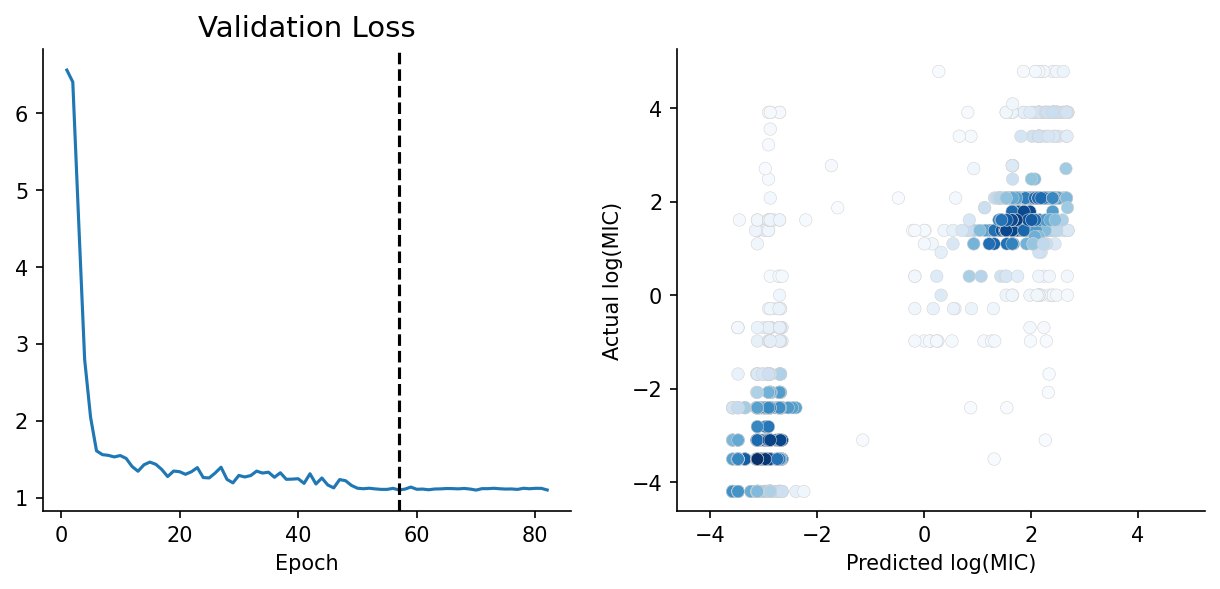

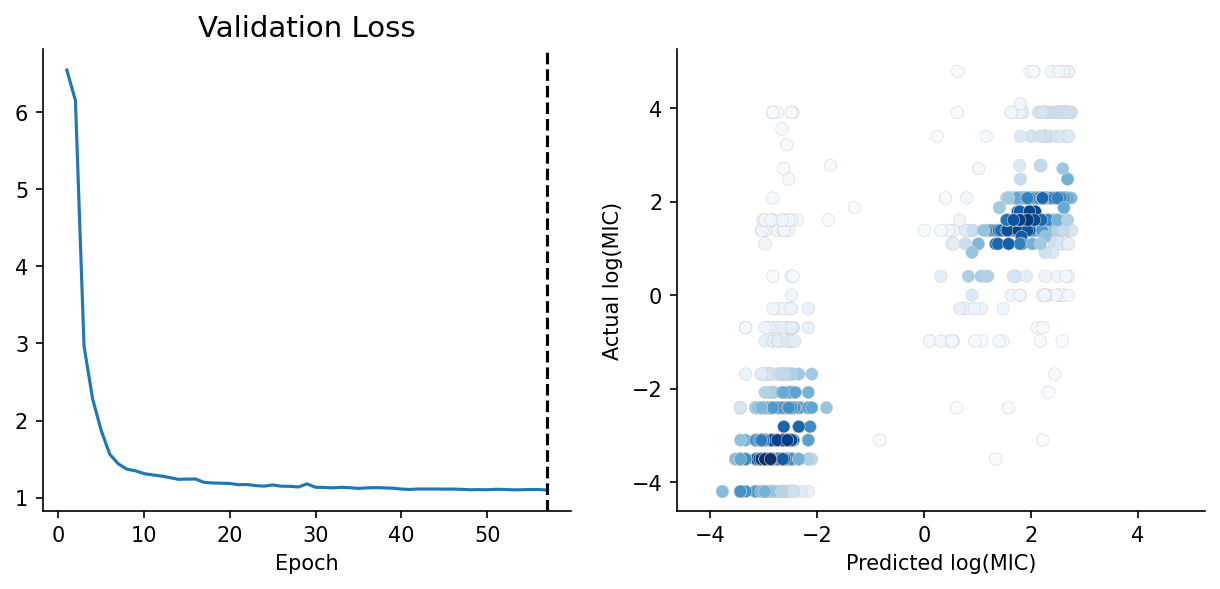

In [ ]:
path_1 = "RIF_rpoBC_new"
rif_CNN = quant_model_analysis(os.path.join(results_path, path_1), "RIF", 0.5, df_rif, 1, lineage=0, patience=25, cv=True, plot=True)
rif_Reg = pd.read_csv(os.path.join(results_path, path_1, "ridge", "ridge_results.csv"))
# rif_binary_CNN = binary_model_analysis(os.path.join(results_path, path_1), "RIF", 0.5, 1, lineage=0, patience=25, cv=True, plot=False)
# rif_binary_Reg = pd.read_csv(os.path.join(results_path, path_1, "ridge", "binary_ridge_results.csv"))

path_2 = "RIF_rpoBC_lineage"
rif_lineage_CNN = quant_model_analysis(os.path.join(results_path, path_2), "RIF", 0.5, df_rif, 1, lineage=1, patience=0, cv=True, plot=True)
rif_lineage_Reg = pd.read_csv(os.path.join(results_path, path_2, "ridge", "ridge_results.csv"))
# rif_lineage_binary_CNN = binary_model_analysis(os.path.join(results_path, path_2), "RIF", 0.5, 1, lineage=1, patience=0, cv=True, plot=False)
# rif_lineage_binary_Reg = pd.read_csv(os.path.join(results_path, path_2, "ridge", "binary_ridge_results.csv"))

# combine all results dataframes for plotting
rif_rpoBC_compare = pd.concat([
                                #rif_binary_CNN, rif_binary_Reg,
                               # rif_lineage_binary_CNN, rif_lineage_binary_Reg,
                               rif_CNN, rif_Reg, 
                               rif_lineage_CNN, rif_lineage_Reg
                              ], axis=0)

rif_rpoBC_compare["Group"] = [1]*22 + [2]*22# + [3]*22 + [4]*22

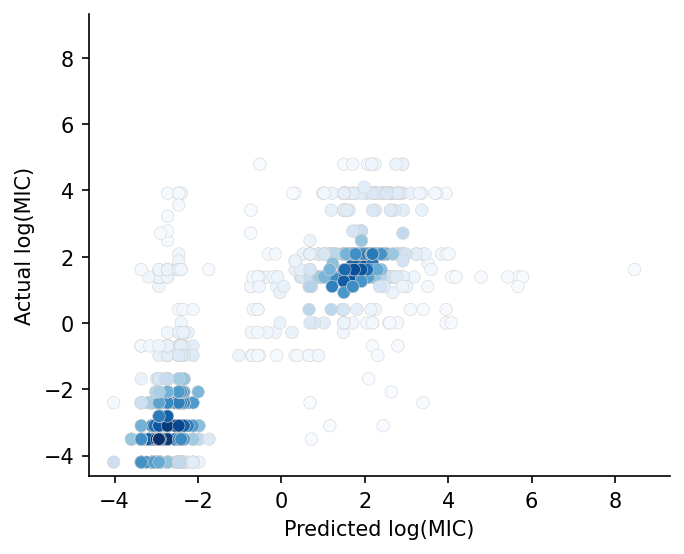

In [26]:
plot_ridge_results(os.path.join(results_path, path_1))

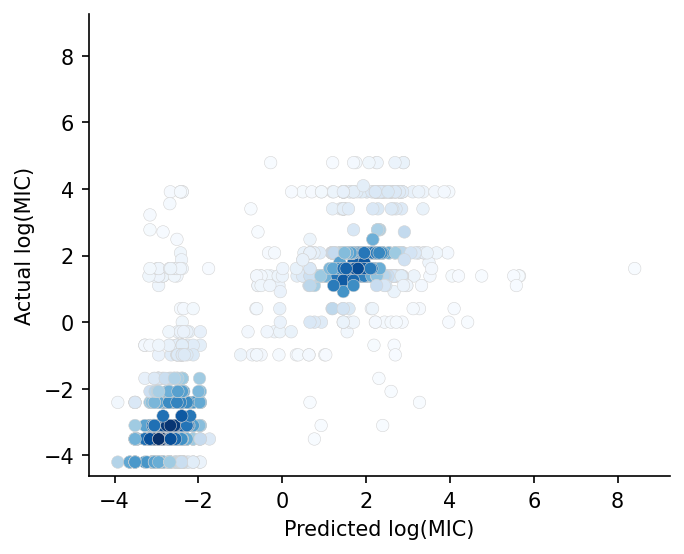

In [27]:
plot_ridge_results(os.path.join(results_path, path_2))

In [28]:
# CNN is significantly better than regression
for var in ["Binned_MAE", "MAE", "Binned_MSE", "MSE", "Pearson", "Within_1bin"]:
    if "MAE" in var or "MSE" in var:
        print(var, test_for_significance(rif_CNN, rif_Reg, var, alt="less"))
    else:
        print(var, test_for_significance(rif_CNN, rif_Reg, var, alt="greater"))

Binned_MAE 2.638324684661834e-07
MAE 1.1235602689239795e-06
Binned_MSE 3.4317245823644366e-10
MSE 1.8381873628783688e-09
Pearson 8.251409255168055e-13
Within_1bin 3.952594209525222e-06


In [29]:
# adding lineage does not significantly affect CNN
for var in ["Binned_MAE", "MAE", "Binned_MSE", "MSE", "Pearson", "Within_1bin"]:
    print(var, test_for_significance(rif_CNN, rif_lineage_CNN, var, alt="two-sided"))

Binned_MAE 0.3351420011012602
MAE 0.6198022644838412
Binned_MSE 0.36890006890198523
MSE 0.12573571538355832
Pearson 0.0016821343934810926
Within_1bin 0.32278859420523676


In [31]:
# adding lineage does not significantly improve regression
for var in ["Binned_MAE", "MAE", "Binned_MSE", "MSE", "Pearson", "Within_1bin"]:
    if "MAE" in var or "MSE" in var:
        print(var, test_for_significance(rif_Reg, rif_lineage_Reg, var, alt="less"))
    else:
        print(var, test_for_significance(rif_Reg, rif_lineage_Reg, var, alt="greater"))

Binned_MAE 0.9474661009488351
MAE 0.6920685588928057
Binned_MSE 0.7612993618678314
MSE 0.40903374553912764
Pearson 0.4899020204389716
Within_1bin 0.4234644221770719


In [44]:
# # not huge differences between binary and quant models for binary metrics
# for var in ["Sensitivity", "Specificity", "AUC", "Balanced_Acc"]:
#     print(var, test_for_significance(rif_CNN, rif_binary_CNN, var, alt="two-sided"))

In [42]:
# # lineage does not significantly change binary model metrics for binary model only
# for var in ["Sensitivity", "Specificity", "AUC", "Balanced_Acc"]:
#     print(var, test_for_significance(rif_binary_CNN, rif_lineage_binary_CNN, var, alt="two-sided"))

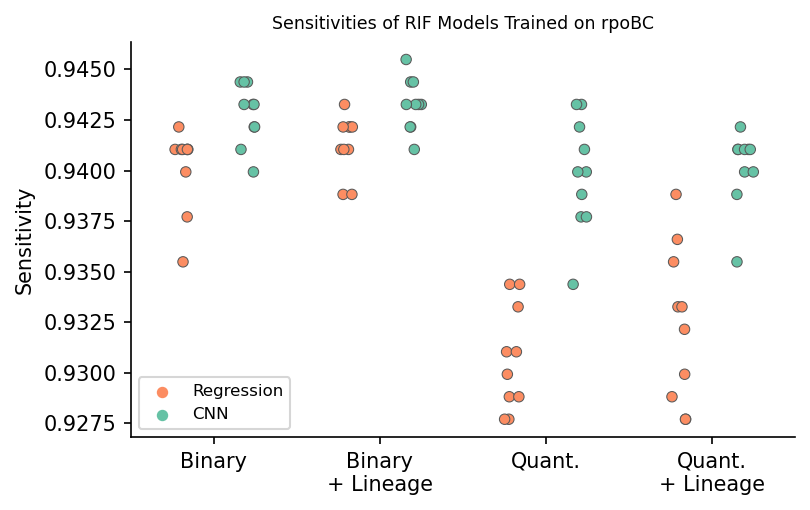

In [22]:
plot_model_results(rif_rpoBC_compare, "Group", "Sensitivity", "Sensitivities of RIF Models Trained on rpoBC", 
                   tick_labels=["Binary", "Binary\n+ Lineage", "Quant.", "Quant.\n+ Lineage"], 
                   plot_width=5.5, legend_loc="lower left",
                  #save_title="/home/sak0914/Figures/rif_sens.png"
                  )

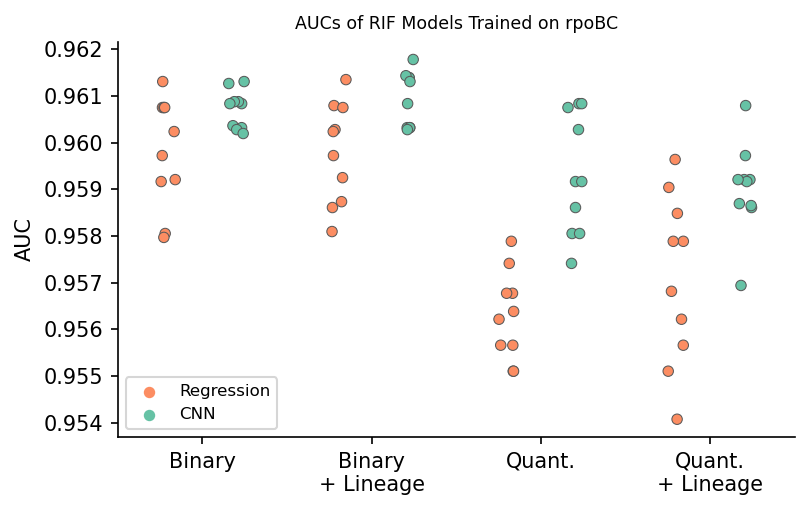

In [23]:
plot_model_results(rif_rpoBC_compare, "Group", "AUC", "AUCs of RIF Models Trained on rpoBC", 
                   tick_labels=["Binary", "Binary\n+ Lineage", "Quant.", "Quant.\n+ Lineage"], 
                   plot_width=5.5, legend_loc="lower left",
                   #save_title="/home/sak0914/Figures/rif_auc.png"
                  )

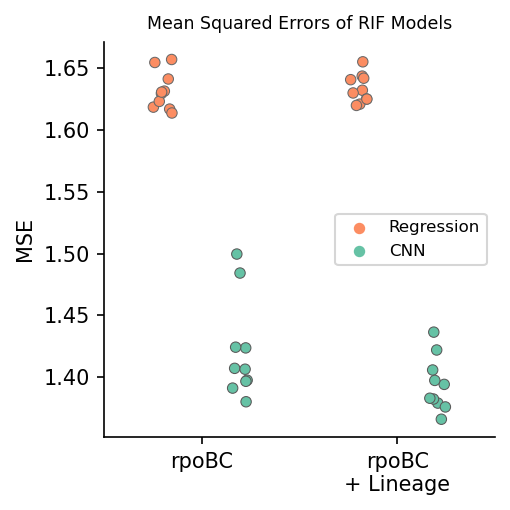

In [36]:
plot_model_results(rif_rpoBC_compare,#.query("Group not in [1, 2]"), 
                   "Group", "MSE", "Mean Squared Errors of RIF Models", 
                   tick_labels=["rpoBC", "rpoBC\n+ Lineage"], plot_width=3.5, legend_loc="best",
                   save_title="figures/RIF/MSE.png"
                 )

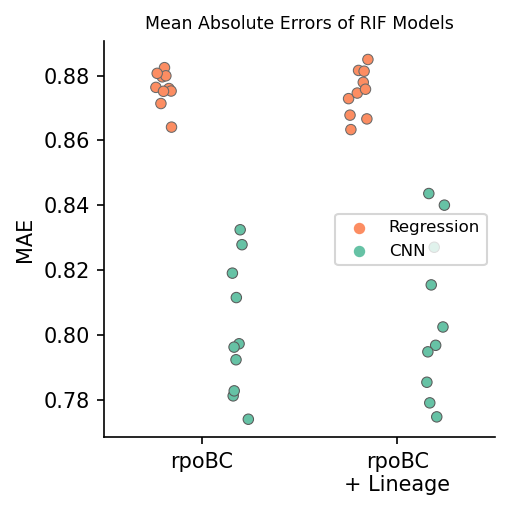

In [38]:
plot_model_results(rif_rpoBC_compare,#.query("Group not in [1, 2]"), 
                   "Group", "MAE", "Mean Absolute Errors of RIF Models", 
                   tick_labels=["rpoBC", "rpoBC\n+ Lineage"], plot_width=3.5, legend_loc="best",
                   save_title="figures/RIF/MAE.png"
                 )

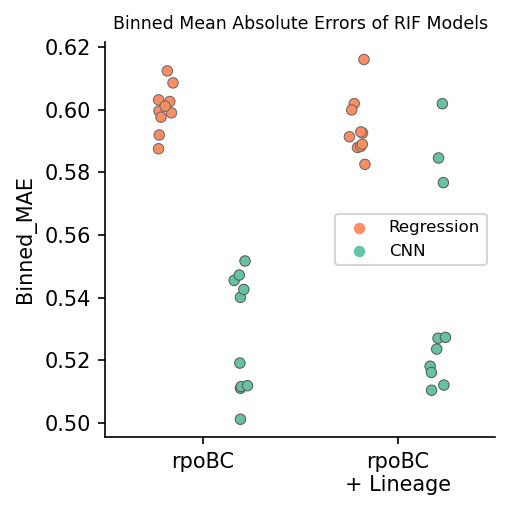

In [40]:
plot_model_results(rif_rpoBC_compare,#.query("Group not in [1, 2]"), 
                   "Group", "Binned_MAE", "Binned Mean Absolute Errors of RIF Models", 
                   tick_labels=["rpoBC", "rpoBC\n+ Lineage"], plot_width=3.5, legend_loc="best",
                   #save_title="figures/RIF/Binned_MAE.png"
                 )

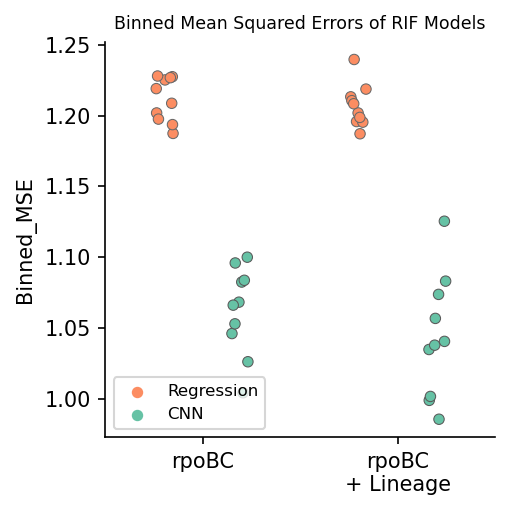

In [41]:
plot_model_results(rif_rpoBC_compare,#.query("Group not in [1, 2]"), 
                   "Group", "Binned_MSE", "Binned Mean Squared Errors of RIF Models", 
                   tick_labels=["rpoBC", "rpoBC\n+ Lineage"], plot_width=3.5, legend_loc="best",
                   #save_title="figures/RIF/Binned_MSE.png"
                 )

In [53]:
# plot_model_results(rif_rpoBC_compare,#.query("Group not in [1, 2]"), 
#                    "Group", "MSE", "Mean Squared Errors of Rifampicin Models", 
#                    tick_labels=["rpoBC", "rpoBC\n+ Lineage"], plot_width=3.5, legend_loc="center right",
#                    #save_title="/home/sak0914/Figures/rif_MAE.png"
#                  )

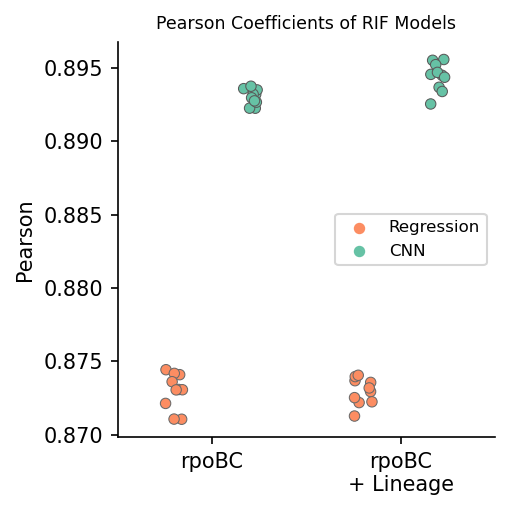

In [42]:
plot_model_results(rif_rpoBC_compare,#.query("Group not in [1, 2]"), 
                   "Group", "Pearson", "Pearson Coefficients of RIF Models", 
                   tick_labels=["rpoBC", "rpoBC\n+ Lineage"], plot_width=3.5, legend_loc="center right",
                   save_title="figures/RIF/Pearson.png"
                 )

# How are Isolates with "Discordant" Mutations Classified?

Q513P, D516V, D516Y

# Moxifloxacin

In [46]:
moxi_gyrBA_binary_CNN = binary_model_analysis(os.path.join(results_path, "MXF_gyrBA"), "MOXI", 0.5, 1, lineage=0, cv=True, plot=False)
moxi_gyrBA_binary_LogReg = pd.read_csv(os.path.join(results_path, "MXF_gyrBA", "ridge", "binary_ridge_results.csv"))

moxi_gyrBA_CNN = quant_model_analysis(os.path.join(results_path, "MXF_gyrBA"), "MOXI", 0.5, df_moxi, 1, lineage=0, cv=True, plot=False)
moxi_gyrBA_LinReg = pd.read_csv(os.path.join(results_path, "MXF_gyrBA", "ridge", "ridge_results.csv"))

moxi_gyrBA_lineage_CNN = quant_model_analysis(os.path.join(results_path, "MXF_gyrBA_lineage"), "MOXI", 0.5, df_moxi, 1, lineage=1, cv=True, plot=False)
moxi_gyrBA_lineage_LinReg = pd.read_csv(os.path.join(results_path, "MXF_gyrBA_lineage", "ridge", "ridge_results.csv"))

moxi_5Loci_CNN = quant_model_analysis(os.path.join(results_path, "MXF_5Loci"), "MOXI", 0.5, df_moxi, 1, lineage=0, patience=25, cv=True, plot=False)
moxi_5Loci_LinReg = pd.read_csv(os.path.join(results_path, "MXF_5Loci", "ridge", "ridge_results.csv"))

moxi_compare = pd.concat([moxi_gyrBA_binary_CNN, moxi_gyrBA_binary_LogReg,
                          moxi_gyrBA_CNN, moxi_gyrBA_LinReg, 
                          moxi_gyrBA_lineage_CNN, moxi_gyrBA_lineage_LinReg,
                          moxi_5Loci_CNN, moxi_5Loci_LinReg
                        ], axis=0)
moxi_compare["Group"] = [1]*22 + [2]*22 + [3]*22 + [4]*22

1460 points in validation set
Trained CNN for 30 epochs
1460 points in validation set
Trained CNN for 87 epochs
1460 points in validation set
Trained CNN for 25 epochs
1460 points in validation set
Trained CNN for 62 epochs


In [86]:
# not huge differences between binary and quant models for binary metrics
for var in ["Sensitivity", "Specificity", "AUC", "Balanced_Acc"]:
    print(var, test_for_significance(moxi_gyrBA_CNN, moxi_gyrBA_binary_CNN, var, alt="less"))

Sensitivity 2.7870511307181276e-05
Specificity 0.9875768277796739
AUC 1.0475061083092898e-05
Balanced_Acc 1.0475061083092898e-05


In [47]:
for var in ["Binned_MAE", "MAE", "Binned_MSE", "MSE", "Pearson", "Within_1bin"]:
    if "MAE" in var or "MSE" in var:
        print(var, test_for_significance(moxi_gyrBA_CNN, moxi_gyrBA_LinReg, var, alt="less"))
    else:
        print(var, test_for_significance(moxi_gyrBA_CNN, moxi_gyrBA_LinReg, var, alt="greater"))

Binned_MAE 0.005633747652150694
MAE 2.7341553998314277e-06
Binned_MSE 0.0008890106737611572
MSE 0.0005009033601741241
Pearson 8.896327323512899e-07
Within_1bin 8.22860127848929e-06


In [48]:
for var in ["Binned_MAE", "MAE", "Binned_MSE", "MSE", "Pearson", "Within_1bin"]:
    if "MAE" in var or "MSE" in var:
        print(var, test_for_significance(moxi_gyrBA_lineage_CNN, moxi_gyrBA_CNN, var, alt="less"))
    else:
        print(var, test_for_significance(moxi_gyrBA_lineage_CNN, moxi_gyrBA_CNN, var, alt="greater"))

Binned_MAE 2.3427985972214807e-08
MAE 1.3811022577174229e-07
Binned_MSE 5.81347919350384e-09
MSE 1.1040765000862462e-08
Pearson 7.860315003972682e-12
Within_1bin 1.834767631033372e-08


In [61]:
for var in ["Binned_MAE", "MAE", "Binned_MSE", "MSE", "Pearson", "Within_1bin"]:
    if "MAE" in var or "MSE" in var:
        print(var, test_for_significance(moxi_gyrBA_lineage_CNN, moxi_gyrBA_lineage_LinReg, var, alt="less"))
    else:
        print(var, test_for_significance(moxi_gyrBA_lineage_CNN, moxi_gyrBA_lineage_LinReg, var, alt="greater"))

Binned_MAE 0.00022274985299135876
MAE 3.4215660665283503e-10
Binned_MSE 1.7316397734245985e-05
MSE 2.508777011637669e-07
Pearson 7.811005893548844e-08
Within_1bin 9.143148784110265e-10


In [59]:
for var in ["Binned_MAE", "MAE", "Binned_MSE", "MSE", "Pearson", "Within_1bin"]:
    if "MAE" in var or "MSE" in var:
        print(var, test_for_significance(moxi_5Loci_CNN, moxi_gyrBA_CNN, var, alt="less"))
    else:
        print(var, test_for_significance(moxi_5Loci_CNN, moxi_gyrBA_CNN, var, alt="greater"))

Binned_MAE 3.425449087819467e-07
MAE 5.12399003036807e-06
Binned_MSE 3.0865917279610517e-07
MSE 2.954196536965786e-07
Pearson 1.5325825973935236e-10
Within_1bin 7.46274162130827e-05


In [61]:
for var in ["Binned_MAE", "MAE", "Binned_MSE", "MSE", "Pearson", "Within_1bin"]:
    if "MAE" in var or "MSE" in var:
        print(var, test_for_significance(moxi_gyrBA_lineage_CNN, moxi_5Loci_CNN, var, alt="less"))
    else:
        print(var, test_for_significance(moxi_gyrBA_lineage_CNN, moxi_5Loci_CNN, var, alt="greater"))

Binned_MAE 3.4109727306377353e-06
MAE 0.09146956923537146
Binned_MSE 2.4490143588607785e-05
MSE 1.2815687008675147e-05
Pearson 5.713823115879856e-07
Within_1bin 0.06191975185410982


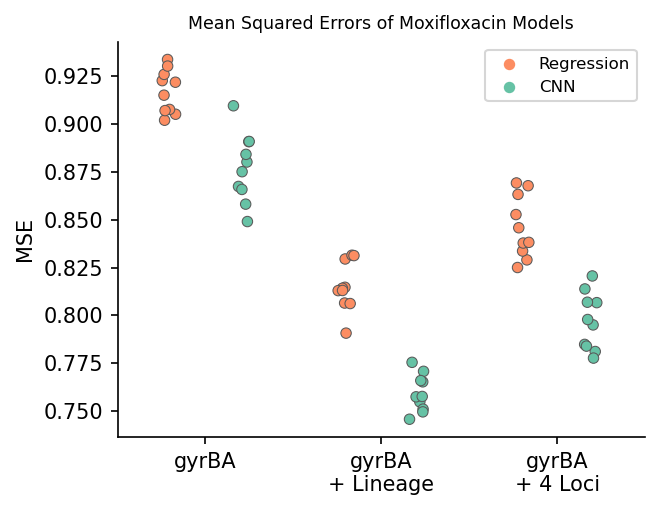

In [62]:
plot_model_results(moxi_compare.query("Group != 1"), "Group", "MSE", "Mean Squared Errors of Moxifloxacin Models", 
                  ["gyrBA", "gyrBA\n+ Lineage", "gyrBA\n+ 4 Loci"],
                   plot_width=4.5,
                  #save_title="/home/sak0914/Figures/moxi_MAE.png"
                 )

In [82]:
np.log(df_moxi["MXF_midpoint"].min()), np.log(df_moxi["MXF_midpoint"].max())

(-4.199705077879927, 2.302585092994046)

In [83]:
2.302585092994046--4.199705077879927

6.502290170873973

In [84]:
np.log(df_rif["RIF_midpoint"].min()), np.log(df_rif["RIF_midpoint"].max())

(-4.199705077879927, 4.787491742782046)

In [85]:
4.787491742782046--4.199705077879927

8.987196820661973

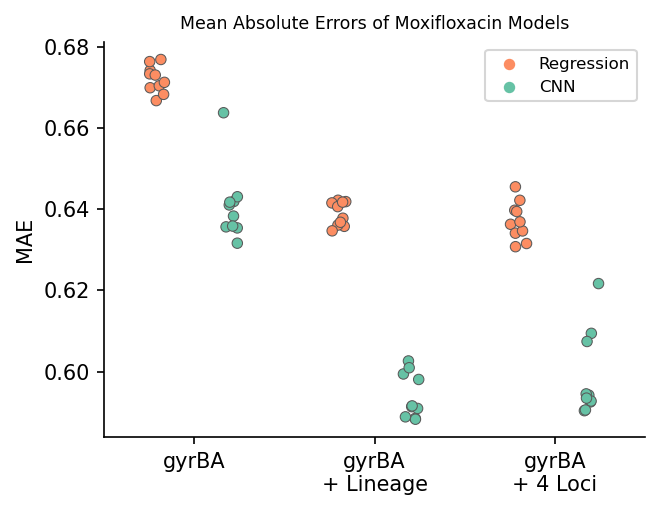

In [63]:
plot_model_results(moxi_compare.query("Group != 1"), "Group", "MAE", "Mean Absolute Errors of Moxifloxacin Models", 
                  ["gyrBA", "gyrBA\n+ Lineage", "gyrBA\n+ 4 Loci"],
                   plot_width=4.5,
                  #save_title="/home/sak0914/Figures/moxi_MAE.png"
                 )

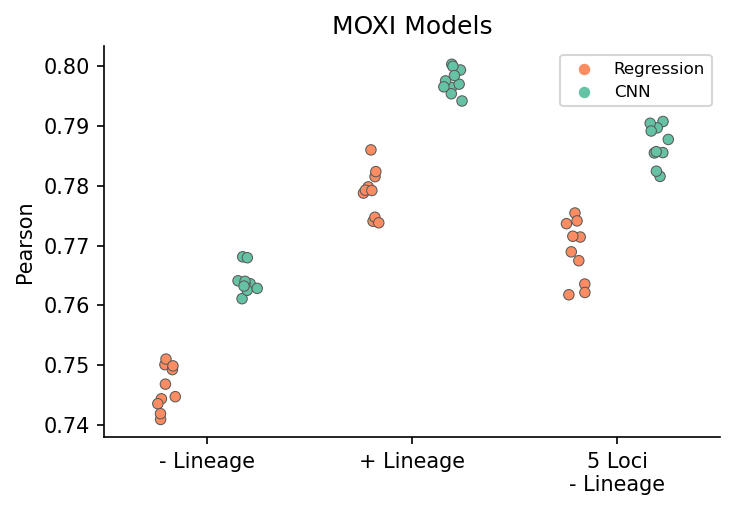

In [119]:
plot_model_results(moxi_compare.query("Group != 1"), "Group", "Pearson", "MOXI Models", 
                  ["- Lineage", "+ Lineage", "5 Loci\n- Lineage"],
                  plot_width=5
                  #save_title="../Figures/moxi_lineage_comparison.png"
                 )

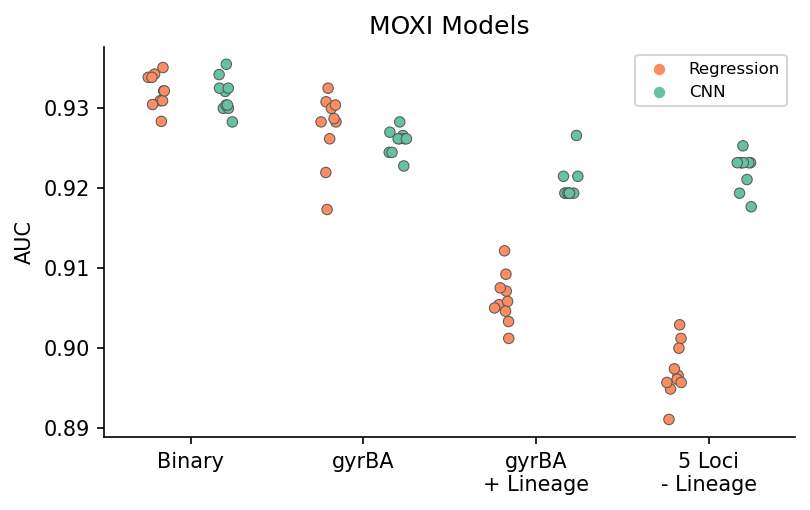

In [124]:
plot_model_results(moxi_compare, "Group", "AUC", "MOXI Models", 
                  ["Binary", "gyrBA", "gyrBA\n+ Lineage", "5 Loci\n- Lineage"],
                  plot_width=5.5
                  #save_title="../Figures/moxi_lineage_comparison.png"
                 )

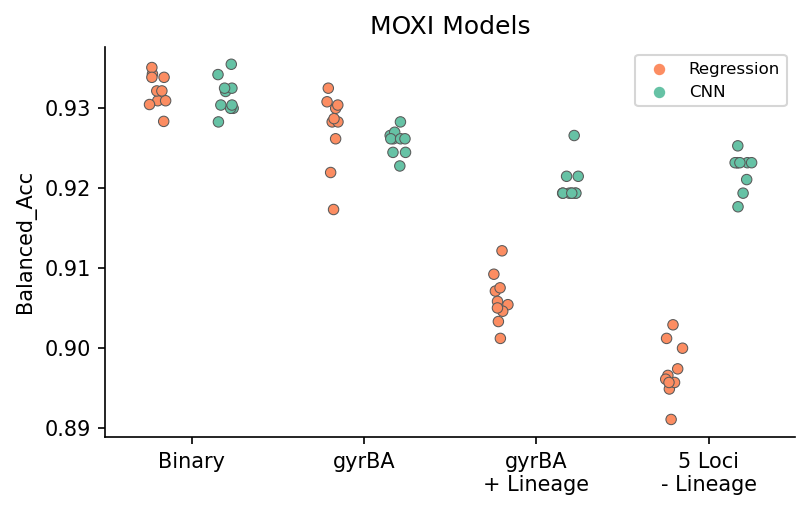

In [125]:
plot_model_results(moxi_compare, "Group", "Balanced_Acc", "MOXI Models", 
                  ["Binary", "gyrBA", "gyrBA\n+ Lineage", "5 Loci\n- Lineage"],
                  plot_width=5.5
                  #save_title="../Figures/moxi_lineage_comparison.png"
                 )

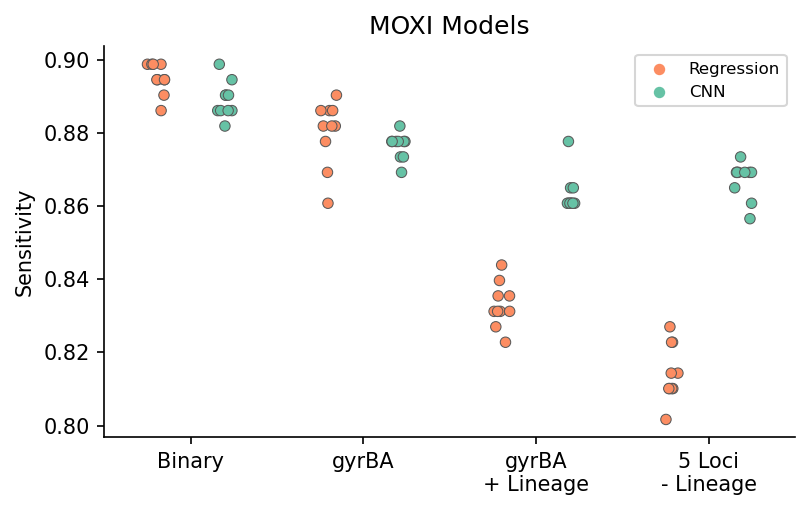

In [126]:
plot_model_results(moxi_compare, "Group", "Sensitivity", "MOXI Models", 
                  ["Binary", "gyrBA", "gyrBA\n+ Lineage", "5 Loci\n- Lineage"],
                  plot_width=5.5
                  #save_title="../Figures/moxi_lineage_comparison.png"
                 )

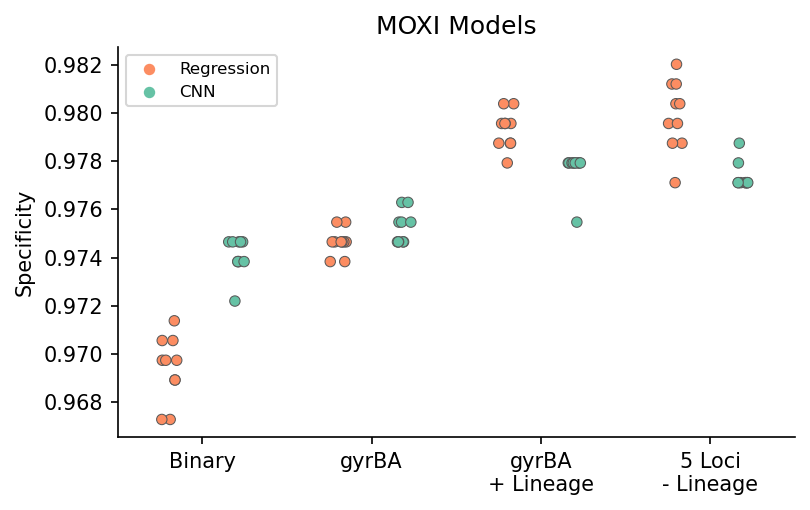

In [127]:
plot_model_results(moxi_compare, "Group", "Specificity", "MOXI Models", 
                  ["Binary", "gyrBA", "gyrBA\n+ Lineage", "5 Loci\n- Lineage"],
                  plot_width=5.5, legend_loc="upper left"
                  #save_title="../Figures/moxi_lineage_comparison.png"
                 )

# Distribution of Mispredictions

In [52]:
def error_dist(cnn_dir):
    
    path = os.path.join(results_path, cnn_dir)
    pred = pd.read_csv(os.path.join(path, "test_predictions.csv"))
    
    sns.histplot(pred.y_pred - pred.y_test, stat="probability")
    plt.axvline(np.mean(pred.y_pred - pred.y_test), color="tomato")
    
    print(np.mean(pred.y_pred - pred.y_test), np.std(pred.y_pred - pred.y_test))
    plt.title("Predicted log-MIC - Actual log-MIC")
    sns.despine()
    plt.show()

0.12428415466526763 0.8912355148197109


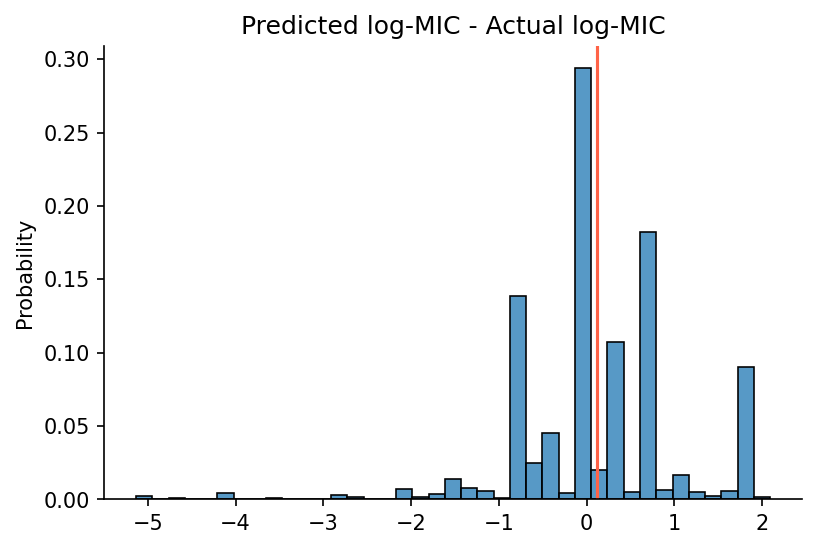

In [53]:
error_dist("20220902_moxi_gyrBA")

-0.006345104482445493 0.8100437303833713


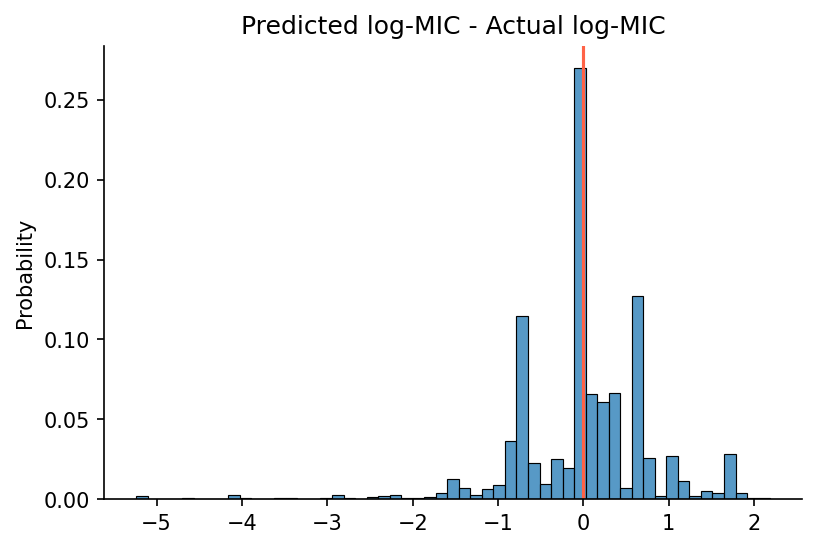

In [54]:
error_dist("20220907_moxi_12Loci")